In [407]:
import pandas as pd

reviews = pd.read_csv("../data/raw/reviews.csv")

In [408]:
reviews.shape

(12495, 12)

In [409]:
def score_to_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

In [410]:
reviews["sentiment"] = reviews["score"].apply(score_to_sentiment)

In [411]:
reviews["sentiment"].value_counts()

sentiment
positive    5654
negative    4850
neutral     1991
Name: count, dtype: int64

In [412]:
reviews["normalised"] = (
    reviews["content"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

In [413]:
reviews.columns

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'sortOrder', 'appId', 'sentiment', 'normalised'],
      dtype='object')

In [414]:
"normalised" in reviews.columns

True

In [415]:
sentiment_counts_per_text = (
    reviews.groupby("normalised")["sentiment"]
    .nunique()
)

In [416]:
conflicting_texts = sentiment_counts_per_text[
    sentiment_counts_per_text > 1
]

In [417]:
len(conflicting_texts)

53

In [418]:
conf_rows = reviews[
    reviews["normalised"].isin(conflicting_texts.index)
]

In [419]:
len(conf_rows)

555

In [420]:
clean_reviews = reviews[
    ~reviews["normalised"].isin(conflicting_texts.index)
].copy()

In [421]:
clean_reviews.shape

(11940, 14)

In [422]:
remaining_conflicts = (
    clean_reviews.groupby("normalised")["sentiment"]
    .nunique()
    .gt(1)
    .sum()
)

remaining_conflicts

np.int64(0)

In [423]:
reviews['sentiment'].value_counts()

sentiment
positive    5654
negative    4850
neutral     1991
Name: count, dtype: int64

In [424]:
reviews[['content','score','sentiment']].isnull().sum()

content      0
score        0
sentiment    0
dtype: int64

In [425]:
reviews['content'].duplicated().sum()

np.int64(688)

In [426]:
dup_content = reviews['content'].duplicated(keep=False)

In [427]:
dup_content = reviews[reviews['content'].duplicated(keep=False)].sort_values('content')

In [428]:
dup_content[
    ["content", "score", "appId", "userName"]
].head(30)

,content,score,appId,userName
7734,A good app,5,com.microsoft.todos,Kiran Gaur
7628,A good app,5,com.microsoft.todos,Yones Visi
4618,Amazing,5,cc.forestapp,Toqa Radwan
2758,Amazing,5,com.ticktick.task,Rofayda Solaiman
4507,Amazing,4,cc.forestapp,Marylex gariando
7545,Amazing,4,com.microsoft.todos,Rashmi Tejas
8523,Amazing,5,prox.lab.calclock,Teodora Mishineva
4585,Amazing,5,cc.forestapp,Ushi Waka
6260,Amazing,5,com.levor.liferpgtasks,Yevhen Dyachenko
12241,Amazing,4,com.appxy.planner,Tomez Abraham


In [429]:
reviews["normalised"] = (
    reviews["content"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

In [430]:
reviews[["content", "normalised"]].head(10)

,content,normalised
0,I cannot open the app anymore,i cannot open the app anymore
1,I have been begging for a refund from this app...,i have been begging for a refund from this app...
2,Very costly for the premium version (approx In...,very costly for the premium version (approx in...
3,"Used to keep me organized, but all the 2020 UP...","used to keep me organized, but all the 2020 up..."
4,Dan Birthday Oct 28,dan birthday oct 28
5,It has changed how I viewed my different lists...,it has changed how i viewed my different lists...
6,I'm only looking for a grocery list app but ev...,i'm only looking for a grocery list app but ev...
7,"Reset my free trial, new phone I'd like to see...","reset my free trial, new phone i'd like to see..."
8,How do to stop monthly payment because i don't...,how do to stop monthly payment because i don't...
9,I complain about not crashes and it was immedi...,i complain about not crashes and it was immedi...


In [431]:
reviews['normalised'].duplicated().sum()

np.int64(758)

In [432]:
sentiment_counts_per_text = (
    reviews.groupby("normalised")["sentiment"]
    .nunique()
)

In [433]:
conflicting_texts = sentiment_counts_per_text[
    sentiment_counts_per_text > 1
]

In [434]:
len(conflicting_texts)

53

In [435]:
print(reviews.groupby("normalised")["sentiment"]
    .nunique())


normalised
"high background usage" sorry, can't waste my battery spyware like this                                                                                      1
"my day" is a great feature. but perhaps it will help to be able to plan it atleast the previous evening.                                                    1
"reminders are a paid feature" that's one of the most basic feature of a to do app!! why even bother to have a free version? this is strictly a paid app.    1
"reminders are a premium feature"                                                                                                                            1
"removed support for google drive backups"                                                                                                                   1
                                                                                                                                                            ..
🙄🙄🙄                                

In [436]:
conf_rows = reviews[
    reviews["normalised"].isin(conflicting_texts.index)
]

In [437]:
len(conf_rows)

555

In [438]:
clean_reviews = reviews[
    ~reviews["normalised"].isin(conflicting_texts.index)
].copy()

In [439]:
remaining_conflicts = (
    clean_reviews.groupby("normalised")["sentiment"]
    .nunique()
    .gt(1)
    .sum()
) 

remaining_conflicts

np.int64(0)

In [440]:
print("Original rows:", len(reviews))
print("Clean rows:", len(clean_reviews))
print("Removed rows:", len(reviews) - len(clean_reviews))

Original rows: 12495
Clean rows: 11940
Removed rows: 555


In [441]:
model_reviews = clean_reviews.drop_duplicates(
    subset=["normalised", "sentiment"]
).copy()

In [442]:
print("Before removing consistent duplicates:", len(clean_reviews))
print("After removing consistent duplicates:", len(model_reviews))
print("Removed repeated rows:", len(clean_reviews) - len(model_reviews))

Before removing consistent duplicates: 11940
After removing consistent duplicates: 11684
Removed repeated rows: 256


In [443]:
model_reviews.duplicated(subset=['normalised', 'sentiment']).sum()

np.int64(0)

In [444]:
print("Before removing consistent duplicates:", len(clean_reviews))
print("After removing consistent duplicates:", len(model_reviews))
print("Removed repeated rows:", len(clean_reviews) - len(model_reviews))

Before removing consistent duplicates: 11940
After removing consistent duplicates: 11684
Removed repeated rows: 256


In [445]:
model_reviews['char_count'] = model_reviews['normalised'].str.len()

In [446]:
model_reviews['word_count'] = model_reviews['normalised'].str.split().str.len()

In [447]:
model_reviews[['content','normalised','char_count','word_count']].head(10)

,content,normalised,char_count,word_count
0,I cannot open the app anymore,i cannot open the app anymore,29,6
1,I have been begging for a refund from this app...,i have been begging for a refund from this app...,89,19
2,Very costly for the premium version (approx In...,very costly for the premium version (approx in...,200,36
3,"Used to keep me organized, but all the 2020 UP...","used to keep me organized, but all the 2020 up...",227,44
4,Dan Birthday Oct 28,dan birthday oct 28,19,4
5,It has changed how I viewed my different lists...,it has changed how i viewed my different lists...,111,22
6,I'm only looking for a grocery list app but ev...,i'm only looking for a grocery list app but ev...,476,101
7,"Reset my free trial, new phone I'd like to see...","reset my free trial, new phone i'd like to see...",62,13
8,How do to stop monthly payment because i don't...,how do to stop monthly payment because i don't...,67,13
9,I complain about not crashes and it was immedi...,i complain about not crashes and it was immedi...,394,76


In [448]:
model_reviews[['char_count','word_count']].describe()

,char_count,word_count
count,11684.000000,11684.000000
mean,157.409534,29.475864
std,153.025217,28.483341
min,1.000000,1.000000
25%,46.000000,9.000000
50%,108.000000,20.000000
75%,222.000000,42.000000
max,4076.000000,723.000000


In [449]:
(model_reviews["word_count"] == 1).sum()

np.int64(226)

In [450]:
model_reviews.loc[
    model_reviews["word_count"] == 1,
    ["content", "normalised", "score", "sentiment", "char_count"]
].head(30)

,content,normalised,score,sentiment,char_count
39,Waste,waste,1,negative,5
44,Dindigul,dindigul,1,negative,8
77,👎,👎,1,negative,1
84,Pratz,pratz,1,negative,5
90,Shabab,shabab,1,negative,6
100,Subscription!!!,subscription!!!,1,negative,15
111,Efvig,efvig,1,negative,5
161,Anydo,anydo,1,negative,5
169,Hf,hf,1,negative,2
172,Virender.kumar,virender.kumar,1,negative,14


In [451]:
model_reviews.nsmallest(
    30,
    "char_count"
)[
    ["content", "normalised", "score", "sentiment", "char_count", "word_count"]
]

,content,normalised,score,sentiment,char_count,word_count
77,👎,👎,1,negative,1,1
2667,🥰,🥰,5,positive,1,1
4614,💜,💜,5,positive,1,1
5172,👌,👌,3,neutral,1,1
5282,😀,😀,3,neutral,1,1
12479,😍,😍,5,positive,1,1
169,Hf,hf,1,negative,2,1
582,Hh,hh,4,positive,2,1
632,Ol,ol,4,positive,2,1
822,😉✌,😉✌,5,positive,2,1


In [452]:
emoji_map = {
    "😍": " positive_emoji ",
    "❤️": " positive_emoji ",
    "❤": " positive_emoji ",
    "💜": " positive_emoji ",
    "💖": " positive_emoji ",
    "👍": " positive_emoji ",
    "😊": " positive_emoji ",
    "😄": " positive_emoji ",
    "😁": " positive_emoji ",
    "🎉": " positive_emoji ",
    "🔥": " positive_emoji ",
    "😉": " positive_emoji ",
    "✌": " positive_emoji ",
    "👌": " positive_emoji ",
    "✨": " positive_emoji ",
    "🥰": " positive_emoji ",
    "😘": " positive_emoji ",
    "😎": " positive_emoji ",
    "😀": " positive_emoji ",

    "👎": " negative_emoji ",
    "😡": " negative_emoji ",
    "😠": " negative_emoji ",
    "😤": " negative_emoji ",
    "😞": " negative_emoji ",
    "😢": " negative_emoji ",
    "😭": " negative_emoji ",
    "💔": " negative_emoji ",
    "🤮": " negative_emoji ",

    "😐": " neutral_emoji ",
    "😑": " neutral_emoji ",
    "🤔": " neutral_emoji ",
}

In [453]:
def replace_emojis(text):
    for emoji, token in emoji_map.items():
        text = text.replace(emoji, token)

    return " ".join(text.split())

In [454]:
model_reviews['model_text'] = (model_reviews['normalised'].apply(replace_emojis))

In [455]:
model_reviews.loc[
    model_reviews["content"].str.contains(
        "😍|👎|👍|😐|💜|❤️",
        regex=True,
        na=False
    ),
    ["content", "normalised", "model_text", "sentiment"]
].head(20)

,content,normalised,model_text,sentiment
77,👎,👎,negative_emoji,negative
233,"Update on 25/8/20 :- worst update ever,, was m...","update on 25/8/20 :- worst update ever,, was m...","update on 25/8/20 :- worst update ever,, was m...",negative
383,I am a paid user of this app. I like this app ...,i am a paid user of this app. i like this app ...,i am a paid user of this app. i like this app ...,negative
695,It's simply the best 😁 ❤️,it's simply the best 😁 ❤️,it's simply the best positive_emoji positive_e...,positive
731,Alot of great features and cry informative and...,alot of great features and cry informative and...,alot of great features and cry informative and...,positive
754,Good app 🙂👍,good app 🙂👍,good app 🙂 positive_emoji,positive
767,Amazing and fantastic app❤️,amazing and fantastic app❤️,amazing and fantastic app positive_emoji,positive
803,Very very helpful and easy to use as well. 'Mu...,very very helpful and easy to use as well. 'mu...,very very helpful and easy to use as well. 'mu...,positive
807,Superb 😍,superb 😍,superb positive_emoji,positive
885,Very nice app👍,very nice app👍,very nice app positive_emoji,positive


In [456]:
print(replace_emojis("great app 😍"))
print(replace_emojis("terrible update 👎"))
print(replace_emojis("it is okay 😐"))

great app positive_emoji
terrible update negative_emoji
it is okay neutral_emoji


In [457]:
model_reviews["has_english_letters"] = (
    model_reviews["model_text"]
    .str.contains(r"[a-z]", regex=True, na=False)
)

In [458]:
(~model_reviews['has_english_letters']).sum()

np.int64(71)

In [459]:
non_eng_or_sym = model_reviews[~model_reviews["has_english_letters"]]

In [460]:
non_eng_or_sym[
    ["content", "normalised", "model_text", "score", "sentiment"]
].head(50)

,content,normalised,model_text,score,sentiment
490,برنامه عالیه اما اکثر امکاناتش پولیه,برنامه عالیه اما اکثر امکاناتش پولیه,برنامه عالیه اما اکثر امکاناتش پولیه,3,neutral
571,還算不錯用！簡單易操作,還算不錯用！簡單易操作,還算不錯用！簡單易操作,4,positive
771,মোবাইল নাম্বার সেটিং অ্যাপ,মোবাইল নাম্বার সেটিং অ্যাপ,মোবাইল নাম্বার সেটিং অ্যাপ,5,positive
774,عالیه,عالیه,عالیه,5,positive
1254,گزینه آندو ش میپره,گزینه آندو ش میپره,گزینه آندو ش میپره,2,negative
1346,يحتاج بال رايق و معقد مو مثل ما اتوقعت وقت ثان...,يحتاج بال رايق و معقد مو مثل ما اتوقعت وقت ثان...,يحتاج بال رايق و معقد مو مثل ما اتوقعت وقت ثان...,2,negative
1401,Базовый функционал платный.,базовый функционал платный.,базовый функционал платный.,3,neutral
1537,"Хорошее приложение. Есть подзадачи, а время и ...","хорошее приложение. есть подзадачи, а время и ...","хорошее приложение. есть подзадачи, а время и ...",4,positive
1946,چطوری باید باهاش کار کنیم؟,چطوری باید باهاش کار کنیم؟,چطوری باید باهاش کار کنیم؟,1,negative
2113,افتضاحه و حال به هم زن ترین برنامه ای است که ت...,افتضاحه و حال به هم زن ترین برنامه ای است که ت...,افتضاحه و حال به هم زن ترین برنامه ای است که ت...,2,negative


In [461]:
english_model_reviews = model_reviews[
    model_reviews["has_english_letters"]
].copy()

In [462]:
print("Before English filtering:", len(model_reviews))
print("After English filtering:", len(english_model_reviews))
print("Rows removed:", len(model_reviews) - len(english_model_reviews))

Before English filtering: 11684
After English filtering: 11613
Rows removed: 71


In [463]:
(~english_model_reviews["has_english_letters"]).sum()

np.int64(0)

In [464]:
english_model_reviews["sentiment"].value_counts()

sentiment
positive    5023
negative    4717
neutral     1873
Name: count, dtype: int64

In [465]:
english_model_reviews["sentiment"].value_counts(normalize=True).mul(100).round(2)

sentiment
positive    43.25
negative    40.62
neutral     16.13
Name: proportion, dtype: float64

In [466]:
x = english_model_reviews['model_text']
y = english_model_reviews['sentiment']

In [467]:
print("X shape:", x.shape)
print("y shape:", y.shape)
print()
print(x.head())
print()
print(y.head())

X shape: (11613,)
y shape: (11613,)

0                        i cannot open the app anymore
1    i have been begging for a refund from this app...
2    very costly for the premium version (approx in...
3    used to keep me organized, but all the 2020 up...
4                                  dan birthday oct 28
Name: model_text, dtype: object

0    negative
1    negative
2    negative
3    negative
4    negative
Name: sentiment, dtype: object


In [468]:
from sklearn.model_selection import train_test_split

In [469]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [470]:
print("Training distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training distribution:
sentiment
positive    43.25
negative    40.62
neutral     16.12
Name: proportion, dtype: float64

Testing distribution:
sentiment
positive    43.26
negative    40.59
neutral     16.14
Name: proportion, dtype: float64


In [471]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [472]:
tfidf = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [473]:
x_train_tfidf = tfidf.fit_transform(x_train)

In [474]:
x_test_tfidf = tfidf.transform(x_test)

In [475]:
print("Training TF-IDF shape:", x_train_tfidf.shape)
print("Testing TF-IDF shape:", x_test_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))

Training TF-IDF shape: (9290, 29631)
Testing TF-IDF shape: (2323, 29631)
Vocabulary size: 29631


In [476]:
from sklearn.linear_model import LogisticRegression

In [477]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [478]:
logistic_model.fit(x_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [479]:
y_pred = logistic_model.predict(x_test_tfidf)

In [480]:
print(len(y_pred))

2323


In [481]:
print(y_pred[:15])

['positive' 'positive' 'negative' 'positive' 'positive' 'negative'
 'negative' 'negative' 'positive' 'negative' 'positive' 'negative'
 'positive' 'positive' 'negative']


In [482]:
from sklearn.metrics import accuracy_score, classification_report

In [483]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.6934997847610848
Accuracy percentage: 69.35 %


In [484]:
print(classification_report(y_test,
                            y_pred,
                            digits = 3))

              precision    recall  f1-score   support

    negative      0.751     0.754     0.752       943
     neutral      0.326     0.397     0.358       375
    positive      0.817     0.747     0.781      1005

    accuracy                          0.693      2323
   macro avg      0.631     0.633     0.630      2323
weighted avg      0.711     0.693     0.701      2323



In [485]:
english_model_reviews.shape

(11613, 18)

In [486]:
english_model_reviews.columns.tolist()

['reviewId',
 'userName',
 'userImage',
 'content',
 'score',
 'thumbsUpCount',
 'reviewCreatedVersion',
 'at',
 'replyContent',
 'repliedAt',
 'sortOrder',
 'appId',
 'sentiment',
 'normalised',
 'char_count',
 'word_count',
 'model_text',
 'has_english_letters']

In [487]:
english_model_reviews[
    ["content", "normalised", "sentiment"]
].head()

,content,normalised,sentiment
0,I cannot open the app anymore,i cannot open the app anymore,negative
1,I have been begging for a refund from this app...,i have been begging for a refund from this app...,negative
2,Very costly for the premium version (approx In...,very costly for the premium version (approx in...,negative
3,"Used to keep me organized, but all the 2020 UP...","used to keep me organized, but all the 2020 up...",negative
4,Dan Birthday Oct 28,dan birthday oct 28,negative


In [488]:
x = english_model_reviews["normalised"]
y = english_model_reviews["sentiment"]

In [489]:
print("X shape:", x.shape)
print("y shape:", y.shape)

print("\nFirst five X values:")
display(x.head())

print("\nFirst five y values:")
display(y.head())

X shape: (11613,)
y shape: (11613,)

First five X values:


0                        i cannot open the app anymore
1    i have been begging for a refund from this app...
2    very costly for the premium version (approx in...
3    used to keep me organized, but all the 2020 up...
4                                  dan birthday oct 28
Name: normalised, dtype: object


First five y values:


0    negative
1    negative
2    negative
3    negative
4    negative
Name: sentiment, dtype: object

In [490]:
print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (11613,)
y shape: (11613,)


In [491]:
print("Missing values in X:", x.isna().sum())

Missing values in X: 0


In [492]:
blank_reviews = x.astype(str).str.strip().eq("").sum()

print("Blank reviews in X:", blank_reviews)

Blank reviews in X: 0


In [493]:
print("Missing values in y:", y.isna().sum())

print("\nUnique sentiment labels:")
print(y.unique())

print("\nNumber of reviews in each class:")
print(y.value_counts())

Missing values in y: 0

Unique sentiment labels:
['negative' 'neutral' 'positive']

Number of reviews in each class:
sentiment
positive    5023
negative    4717
neutral     1873
Name: count, dtype: int64


In [494]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [495]:
print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9290,)
X_test shape: (2323,)
y_train shape: (9290,)
y_test shape: (2323,)


In [496]:
print("Full dataset proportions:")
print(y.value_counts(normalize=True))

print("\nTraining-set proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting-set proportions:")
print(y_test.value_counts(normalize=True))

Full dataset proportions:
sentiment
positive    0.432533
negative    0.406183
neutral     0.161285
Name: proportion, dtype: float64

Training-set proportions:
sentiment
positive    0.432508
negative    0.406243
neutral     0.161249
Name: proportion, dtype: float64

Testing-set proportions:
sentiment
positive    0.432630
negative    0.405941
neutral     0.161429
Name: proportion, dtype: float64


In [497]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [498]:
tfidf = TfidfVectorizer()

In [499]:
x_train_tfidf = tfidf.fit_transform(x_train)

In [500]:
x_test_tfidf = tfidf.transform(x_test)

In [501]:
print("Original X_train shape:", x_train.shape)
print("TF-IDF training shape:", x_train_tfidf.shape)

print("\nOriginal X_test shape:", x_test.shape)
print("TF-IDF testing shape:", x_test_tfidf.shape)

Original X_train shape: (9290,)
TF-IDF training shape: (9290, 10385)

Original X_test shape: (2323,)
TF-IDF testing shape: (2323, 10385)


In [502]:
feature_names = tfidf.get_feature_names_out()

print("Vocabulary size:", len(feature_names))
print("First 30 features:")
print(feature_names[:30])

Vocabulary size: 10385
First 30 features:
['00' '000' '00am' '00hrm' '00pm' '01' '01x0' '0365' '03pm' '04' '05'
 '0528' '06' '07' '08' '09' '10' '100' '1000' '100php' '100x' '101' '10am'
 '10min' '10mins' '10pm' '10x' '11' '11am' '11pm']


In [503]:
logistic_model.fit(x_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [504]:
y_pred_model = logistic_model.predict(x_test_tfidf)

In [505]:
print("Test reviews:", len(y_test))
print("Predictions:", len(y_pred_model))

Test reviews: 2323
Predictions: 2323


In [506]:
prediction_preview = x_test.reset_index(drop=True).to_frame(name="review")

prediction_preview["actual"] = y_test.reset_index(drop=True)
prediction_preview["predicted"] = y_pred_model

display(prediction_preview.head(10))

,review,actual,predicted
0,great app for planning my day,positive,positive
1,i'm using app for pomedro method. set 25 minut...,positive,positive
2,do not buy premium! devs are not responsive an...,negative,negative
3,this app is great! i love the idea of turning ...,positive,positive
4,easy to use but needs better or customizable c...,neutral,positive
5,i would honestly give this app a chance if mor...,neutral,negative
6,too complicated so uninstalled but still getti...,negative,negative
7,"over priced, under developed app. the free ver...",neutral,negative
8,"incredible, the best app of organization.",positive,positive
9,how to view the app on laptop? just like wunde...,neutral,negative


In [507]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification report:")
print(classification_report(y_test, y_pred_model))

Accuracy: 0.6934997847610848

Classification report:
              precision    recall  f1-score   support

    negative       0.75      0.71      0.73       943
     neutral       0.30      0.44      0.36       375
    positive       0.83      0.73      0.77      1005

    accuracy                           0.67      2323
   macro avg       0.63      0.63      0.62      2323
weighted avg       0.71      0.67      0.69      2323



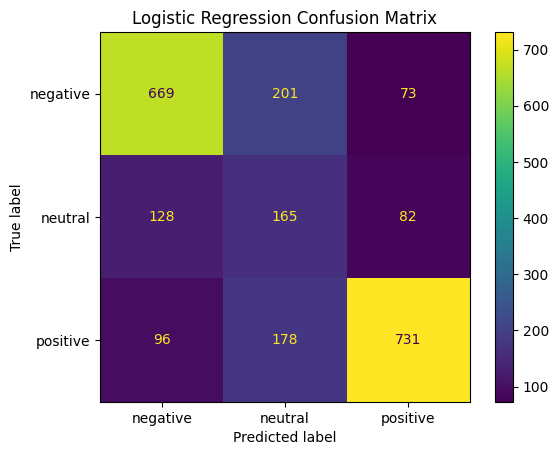

In [508]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["negative", "neutral", "positive"]

cm = confusion_matrix(
    y_test,
    y_pred_model,
    labels=labels
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

display_matrix.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Logistic Regression accuracy:
0.673697804563065

Classification report:
              precision    recall  f1-score   support

    negative     0.7492    0.7094    0.7288       943
     neutral     0.3033    0.4400    0.3591       375
    positive     0.8251    0.7274    0.7731      1005

    accuracy                         0.6737      2323
   macro avg     0.6258    0.6256    0.6203      2323
weighted avg     0.7100    0.6737    0.6883      2323


Confusion matrix:
[[669 201  73]
 [128 165  82]
 [ 96 178 731]]


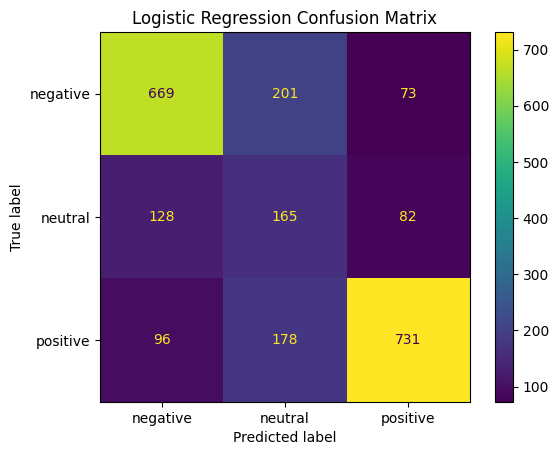

In [509]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Generate predictions once
logreg_predictions = logistic_model.predict(X_test_tfidf)

# Calculate all metrics from the same prediction variable
logreg_accuracy = accuracy_score(
    y_test,
    logreg_predictions
)

print("Logistic Regression accuracy:")
print(logreg_accuracy)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        logreg_predictions,
        digits=4
    )
)

labels = ["negative", "neutral", "positive"]

logreg_cm = confusion_matrix(
    y_test,
    logreg_predictions,
    labels=labels
)

print("\nConfusion matrix:")
print(logreg_cm)

logreg_display = ConfusionMatrixDisplay(
    confusion_matrix=logreg_cm,
    display_labels=labels
)

logreg_display.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [510]:
from sklearn.linear_model import LogisticRegression

balanced_logreg_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

In [511]:
balanced_logreg_model.fit(
    x_train_tfidf,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [512]:
balanced_logreg_predictions = balanced_logreg_model.predict(
    x_test_tfidf
)

Balanced Logistic Regression accuracy:
0.673697804563065

Classification report:
              precision    recall  f1-score   support

    negative     0.7492    0.7094    0.7288       943
     neutral     0.3033    0.4400    0.3591       375
    positive     0.8251    0.7274    0.7731      1005

    accuracy                         0.6737      2323
   macro avg     0.6258    0.6256    0.6203      2323
weighted avg     0.7100    0.6737    0.6883      2323


Confusion matrix:
[[669 201  73]
 [128 165  82]
 [ 96 178 731]]


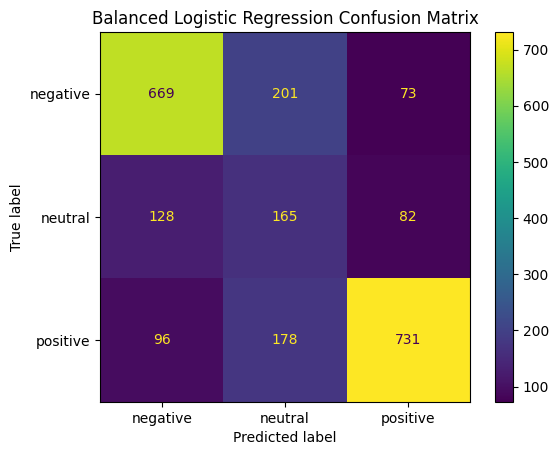

In [513]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

balanced_logreg_accuracy = accuracy_score(
    y_test,
    balanced_logreg_predictions
)

print("Balanced Logistic Regression accuracy:")
print(balanced_logreg_accuracy)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        balanced_logreg_predictions,
        digits=4
    )
)

labels = ["negative", "neutral", "positive"]

balanced_logreg_cm = confusion_matrix(
    y_test,
    balanced_logreg_predictions,
    labels=labels
)

print("\nConfusion matrix:")
print(balanced_logreg_cm)

balanced_logreg_display = ConfusionMatrixDisplay(
    confusion_matrix=balanced_logreg_cm,
    display_labels=labels
)

balanced_logreg_display.plot()
plt.title("Balanced Logistic Regression Confusion Matrix")
plt.show()

In [514]:
from sklearn.linear_model import LogisticRegression

unweighted_logreg_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight=None
)

In [516]:
unweighted_logreg_model.fit(
    x_train_tfidf,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [517]:
unweighted_logreg_predictions = unweighted_logreg_model.predict(
    x_test_tfidf
)

In [518]:
balanced_logreg_predictions = balanced_logreg_model.predict(
    x_test_tfidf
)

In [519]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def get_model_metrics(y_true, predictions):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        predictions,
        labels=["negative", "neutral", "positive"],
        zero_division=0
    )

    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        predictions,
        average="macro",
        zero_division=0
    )

    _, _, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy_score(y_true, predictions),
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "negative_f1": f1[0],
        "neutral_f1": f1[1],
        "positive_f1": f1[2]
    }

In [520]:
unweighted_metrics = get_model_metrics(
    y_test,
    unweighted_logreg_predictions
)

balanced_metrics = get_model_metrics(
    y_test,
    balanced_logreg_predictions
)

print("Unweighted Logistic Regression:")
print(unweighted_metrics)

print("\nBalanced Logistic Regression:")
print(balanced_metrics)

Unweighted Logistic Regression:
{'accuracy': 0.7137322427894963, 'macro_f1': 0.5635776644935832, 'weighted_f1': 0.6757151415248873, 'negative_f1': np.float64(0.7679611650485437), 'neutral_f1': np.float64(0.129979035639413), 'positive_f1': np.float64(0.7927927927927928)}

Balanced Logistic Regression:
{'accuracy': 0.673697804563065, 'macro_f1': 0.6203266799551521, 'weighted_f1': 0.6882814364342572, 'negative_f1': np.float64(0.7287581699346405), 'neutral_f1': np.float64(0.3590859630032644), 'positive_f1': np.float64(0.7731359069275515)}


In [521]:
from sklearn.svm import LinearSVC

balanced_svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

In [522]:
balanced_svm_model.fit(
    x_train_tfidf,
    y_train
)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


In [523]:
balanced_svm_predictions = balanced_svm_model.predict(
    x_test_tfidf
)

In [524]:
balanced_svm_metrics = get_model_metrics(
    y_test,
    balanced_svm_predictions
)

print("Balanced Linear SVM:")
print(balanced_svm_metrics)

Balanced Linear SVM:
{'accuracy': 0.6861816616444253, 'macro_f1': 0.6029883659394323, 'weighted_f1': 0.6846918553717292, 'negative_f1': np.float64(0.7380073800738007), 'neutral_f1': np.float64(0.28843537414965986), 'positive_f1': np.float64(0.7825223435948362)}


In [525]:
from sklearn.metrics import classification_report, confusion_matrix

print(
    classification_report(
        y_test,
        balanced_svm_predictions,
        digits=4
    )
)

print(
    confusion_matrix(
        y_test,
        balanced_svm_predictions,
        labels=["negative", "neutral", "positive"]
    )
)

              precision    recall  f1-score   support

    negative     0.7338    0.7423    0.7380       943
     neutral     0.2944    0.2827    0.2884       375
    positive     0.7810    0.7841    0.7825      1005

    accuracy                         0.6862      2323
   macro avg     0.6031    0.6030    0.6030      2323
weighted avg     0.6833    0.6862    0.6847      2323

[[700 139 104]
 [152 106 117]
 [102 115 788]]
